# **Atividade Prática**
<font size=3>

- **Tema:** dados desbalanceados.
- **Prazo de entrega:** 04 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Com base no *dataset* de [Detecção de avaliações falsas em árabe](https://www.kaggle.com/datasets/shathaalturke/afrd-arabic-fake-reviews-detection), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a tarefa de classificação:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e **imprima na tela** o dataframe e o número de resenhas;
- Utilize a função [`unique`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html) para identificar as categorias do atributo `Gender`. Caso você identifique algum problema nesse atributo, corrija essa coluna;
- Transformer o atributo `Age` para que o intervalo das idades seja definida como a média, *e.g.*, $[20,\, 40) \rightarrow 30$;
- Defina a variável de atributos `X` com os atributos `Age`, `Gender`, `Rating` e `Text`, e a variável also `y` como o atributo `Polarity`.


##### Definições gerais e imports

In [1]:
import re
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.corpus   import stopwords
from nltk.corpus   import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, normalize

In [2]:
RANDOM_STATE=42 # semente para garantir a reprodutibilidade dos resultados
TEST_SIZE=0.10 # proporção de dados para teste
SVD_COMPONENTS=25 # número de componentes para o SVD
N_ITER=10 # número de iterações para o RandomizedSearchCV

##### Lendo os dados (do disco local)

In [3]:
df = pd.read_csv("./dataset/arabic.csv", index_col=0) # estou executando no meu notebook pessoal, não no google colab.

print(df.shape)

df.head()

(405, 6)


,Age,Gender,Name,Rating,Text,Polarity
0,[20-30),Female,Gloria Inn,4,جودة الخدمة رائعة والغرف مرتبة ونظيفة أنصحكم فيه,Positive
1,[20-30),Female,Jareed,5,هل أتحدث عن جمال الغرفة أم عن جمال الفندق أم ع...,Positive
2,[20-30),Female,fourseasons,1,الموظفيين لا اسلوب ولا تعامل خصوصا اللي باللوب...,Negative
3,[20-30),Female,Gloria Inn,5,تعامل الموظفين مؤدب مره وحلو ويعاملونك مثل ضيف...,Positive
4,[20-30),Female,Gloria Inn,1,تجربة سيئة جدا مع هذا الفندق التكييف كان حار ج...,Negative


##### Investigando e Limpando ```Gender```

In [4]:
pd.unique(df['Gender'])


<StringArray>
['Female', 'female', 'male']
Length: 3, dtype: str

In [5]:
df['Gender'].value_counts()

Gender
Female    250
female     99
male       56
Name: count, dtype: int64

In [6]:
df.loc[df['Gender'] == 'female', 'Gender'] = 'Female'
df.loc[df['Gender'] == 'male', 'Gender'] = 'Male'
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

In [7]:
df['Gender'].value_counts()

Gender
1    349
0     56
Name: count, dtype: int64

##### Investigando e Limpando ```Age```

In [8]:
pd.unique(df['Age'])

<StringArray>
[   '[20-30)',    '[50-60)',    '[30-40)',    '[40-50)', '[under 20)',
   'under 20',    '[20-40)',    '[20-30]']
Length: 8, dtype: str

In [9]:
df['Age'].value_counts().sort_index()

Age
[20-30)       348
[20-30]         1
[20-40)         1
[30-40)         8
[40-50)        35
[50-60)         3
[under 20)      1
under 20        8
Name: count, dtype: int64

In [10]:
def age_to_int(age_range):
  age_range = re.sub(r"[^0-9-'\s]", " ", age_range)
  age_range = re.findall(r"(\d+)", age_range)
  age_range = [int(age) for age in age_range]
  age_range = int(np.mean(age_range))
  return age_range

df['Age'] = df['Age'].apply(age_to_int)

In [11]:
df['Age'].value_counts().sort_index()

Age
20      9
25    349
30      1
35      8
45     35
55      3
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Age       405 non-null    int64
 1   Gender    405 non-null    int64
 2   Name      405 non-null    str  
 3   Rating    405 non-null    int64
 4   Text      405 non-null    str  
 5   Polarity  405 non-null    str  
dtypes: int64(3), str(3)
memory usage: 19.1 KB


In [13]:
df.describe()

,Age,Gender,Rating
count,405.000000,405.000000,405.000000
mean,27.049383,0.861728,3.412346
std,6.302799,0.345612,1.654680
min,20.000000,0.000000,1.000000
25%,25.000000,1.000000,2.000000
50%,25.000000,1.000000,4.000000
75%,25.000000,1.000000,5.000000
max,55.000000,1.000000,5.000000


##### Preparando conjuntos de dados completo (X) e (y)

Conforme instruído em classe, devemos eliminar ```Rating``` pois o modelo aprenderia muito facilmente a partir da correlação existente com o sentimento. Eliminamos ```Name``` pois não traz informação relevante para a tarefa, e ```Polarity``` por que é nossa variável alvo (Y) 

In [14]:
X = df.drop(['Polarity', 'Name', 'Rating'], axis=1)
X.head()

,Age,Gender,Text
0,25,1,جودة الخدمة رائعة والغرف مرتبة ونظيفة أنصحكم فيه
1,25,1,هل أتحدث عن جمال الغرفة أم عن جمال الفندق أم ع...
2,25,1,الموظفيين لا اسلوب ولا تعامل خصوصا اللي باللوب...
3,25,1,تعامل الموظفين مؤدب مره وحلو ويعاملونك مثل ضيف...
4,25,1,تجربة سيئة جدا مع هذا الفندق التكييف كان حار ج...


In [15]:

y = df['Polarity']
y.head()

0    Positive
1    Positive
2    Negative
3    Positive
4    Negative
Name: Polarity, dtype: str

### **2º Passo:**
<font size=3>

- Utilize a função `unique` para identificar as proporções das classes da variável `y`;
- Realize a divisão dos dados entre treinamento e teste. Caso seja necessário, faça a estratificação;
- Utilize a classe [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar `y_train` e `y_test`;
- Para transformar os dados de atributos:
    - Defina o transformador de texto com o objeto [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear a vetorização TF-IDF e a redimensionalização SVD. Para a variável `preprocessor` de `TfidfVectorizer` use uma função para eliminar dígitos em sequência e espaços em excesso;
    - Defina o transformador dos dados categóricos com os atributos `Gender` e `Rating`;
    - Defina o transformador do dado numérico `Age`.
- Defina o objeto preprocessador com a classe [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

##### Investigando balanceamento das classes

In [16]:
y.value_counts()

Polarity
Positive    239
Negative    166
Name: count, dtype: int64

##### Separando conjuntos de treino e teste

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42, stratify=y)

X_train.head(5)

,Age,Gender,Text
51,25,1,الغرفة واسعة ومريحة وفيها آلة قهوة وجميع الخدم...
48,25,1,الاسعار مبالغ فيها سواء حجز او بوفيه المشكله م...
64,20,1,خدمة ممتازة وطعام افطار جيد لكن تم حساب ٢٠٠ ري...
296,25,0,الفندق عادي حجم الغرف متوسط بس نظيفة ومرتبة ال...
28,25,1,من افضل الفنادق اللي زرتها غرف واسعة وشرحة ومو...


##### Codificando as classes

In [18]:
# definindo o codificador de etiquetas:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train) # fit e transformação
y_test_encoded = le.transform(y_test) # apenas transformação!

classes = le.classes_
print(f"Alvos antes da codificação: {classes}")
print(f"Alvos depois da codificação: {np.unique(y_train_encoded)}")


Alvos antes da codificação: ['Negative' 'Positive']
Alvos depois da codificação: [0 1]


##### Função de pre-processamento de texto

In [19]:
def preprocess_text(text):
  
    text = re.sub(r"\s+", " ", text)           # substitui múltiplos espaços por um único espaço
    text = re.sub(r"\d+", "", text)            # remove dígitos
    text = text.strip()                        # remove espaços em branco no início e no final

    return text

##### Definindo transformações de pré-processamento dos dados

In [20]:
# Definindo a coluna e o tipo de transformação:
# 1. texto:
text_atribute = "Text"
text_pipe = Pipeline(steps=[
    ("vec", TfidfVectorizer(preprocessor=preprocess_text)),
    ("svd", TruncatedSVD())
])

# 2. dados categóricos:
#categorical_atributes = ['Product', 'Brand']
#categorical_transformer = OneHotEncoder()

# 3. dados numéricos:
numerical_atributes = ['Age']
numeric_transformer = StandardScaler()

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor = ColumnTransformer(transformers=[("text", text_pipe, text_atribute),
                                               ('num', numeric_transformer, numerical_atributes)],
                                 remainder='passthrough' # categorias que não forem identificadas serão consideradas, mas sem transformação
                                )

# visualizando o objeto processador:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### **3º Passo:**
<font size=3>

- Defina o objeto de `Pipeline` para encadear o objeto preprocessador e o modelo de [máquina de vetores de suporte](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html);
- Para treinar o modelo, utilize a classe [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) considerando:
    - A grade de parâmetros `min_df` e `max_df` (**TfidfVectorizer**); `n_components` (**SVD**); `C`, `kernel` e `gamma` (*support vector classifier* — **SVC**);        
    - 10 iterações na busca de hiperparâmetros;
    - 5 divisões para validação cruzada;
    - Métrica acurácia.
- **Imprima na tela** os melhores hiperparâmetros e valor de acurácia.
- Em relação os hiperparâmetros do modelo e pré-procressador, **escreva** em uma **célula markdown** sua interpretação quanto à **filtragem de _tokens_** durante a vetorização, **tamanho da vetor semântico** e **tipo de _kernel_** do modelo.

##### Definindo Pipeline Completo

In [21]:
pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', SVC())])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

##### Definindo Espaço de Busca de Hiperparametros

In [22]:
param_grid = {"preprocessor__text__vec__min_df": [5, 10],
              "preprocessor__text__vec__max_df": [0.950, 0.975],
              'preprocessor__text__svd__n_components':[25, 50], # com 100 features levanta erro (num features = 73)
              'classifier__C': [0.1, 1, 10],
              'classifier__kernel': ['linear', 'rbf'],
              'classifier__gamma': ['scale', 0.01, 0.1]
             }

random_search = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_grid,
                                 n_iter=N_ITER,
                                 cv=5,
                                 scoring='accuracy',
                                 verbose=1, 
                                 random_state=RANDOM_STATE)

random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ier', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 0.01, ...], 'classifier__kernel': ['linear', 'rbf'], 'preprocessor__text__svd__n_components': [25, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscros

#### Executando o RandomSearchCV

In [23]:
random_search.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ier', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 0.01, ...], 'classifier__kernel': ['linear', 'rbf'], 'preprocessor__text__svd__n_components': [25, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscros

In [24]:
print(f"Melhores parâmetros encontrados: {random_search.best_params_}")
print(f"Melhor score de acurácia (validação cruzada): {random_search.best_score_:.4f}")

Melhores parâmetros encontrados: {'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.975, 'preprocessor__text__svd__n_components': 25, 'classifier__kernel': 'linear', 'classifier__gamma': 0.01, 'classifier__C': 1}
Melhor score de acurácia (validação cruzada): 0.8296


### **4º Passo:**
<font size=3>

- Realize as predições com os dados de teste;
- Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) para plotar a **matriz de confusão**;
- Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para **imprimir na tela** os resultados da classificação;
- **Escreva** em uma **célula markdown** sua interpretação da **matriz de confusão**.

##### Testando o melhor modelo

In [28]:
y_pred = random_search.predict(X_test)

acc = accuracy_score(y_test_encoded, y_pred)

print(f"Acurácia do melhor modelo no conjunto de teste: {acc:.4f}")

Acurácia do melhor modelo no conjunto de teste: 0.8049


##### Análise Final

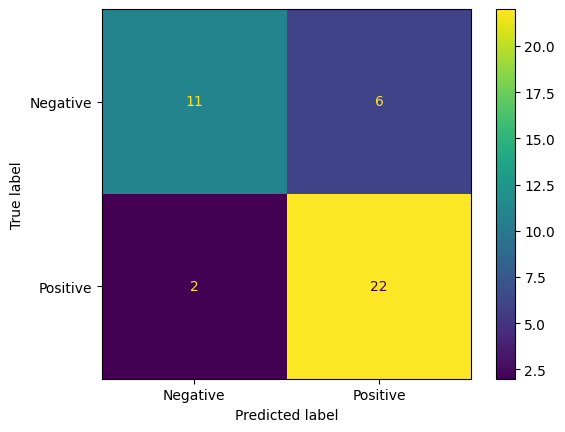

In [26]:
cm = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()

plt.show()

In [27]:
print(classification_report(y_test_encoded, y_pred, target_names=classes, digits=4))

              precision    recall  f1-score   support

    Negative     0.8462    0.6471    0.7333        17
    Positive     0.7857    0.9167    0.8462        24

    accuracy                         0.8049        41
   macro avg     0.8159    0.7819    0.7897        41
weighted avg     0.8108    0.8049    0.7994        41



O modelo apresentou desempenho consistente, com acurácia de 0.8049 no conjunto de teste. Observamos maior capacidade de identificação da classe positiva (recall de 0.9167) em comparação com a classe negativa (recall de 0.6471), indicando uma leve tendência do classificador em favorecer previsões positivas.

Ainda assim, os valores de f1-score para ambas as classes (0.7333 para negativa e 0.8462 para positiva), bem como as médias macro (0.7897) e ponderada (0.7994), indicam um bom equilíbrio entre precisão e recall.

A diferença reduzida entre a acurácia obtida na validação cruzada (0.8296) e no conjunto de teste (0.8049) sugere boa capacidade de generalização, sem evidências de sobreajuste relevante.